In [1]:
const LAB19_ROOT = pwd()
using Random, Statistics, LinearAlgebra
using FileIO, ImageIO, ImageTransformations, Colors, Plots

default(; size = (700, 400), fmt = :png, show = false)

plot_cache_dir() = mkpath(joinpath(LAB19_ROOT, ".plot_display_cache"))

function showplot(p = Plots.current())
    d = plot_cache_dir()
    path = joinpath(d, string(time_ns(), ".png"))
    try
        Plots.savefig(p, path)
        display(MIME("image/png"), read(path))
    finally
        rm(path; force = true)
    end
    Plots.closeall()
    return nothing
end

showplot (generic function with 2 methods)

In [2]:
const IMG_SIZE = 150
const CANVAS_REF = 120.0  



const BASE_GENE_COUNT = 16

const COLOR_GENE_COUNT = 3
const GENE_COUNT = BASE_GENE_COUNT + COLOR_GENE_COUNT

"""Нормализация направления dir к 0..7 (как в JS: ((dir % 8) + 8) % 8)."""
mod8(dir::Int) = mod(dir, 8)

function calculate_stems(g::AbstractVector{Int})
    g1, g2, g3, g4, g5, g6, g7 = g[1], g[2], g[3], g[4], g[5], g[6], g[7]
    return [
        (0, g1),
        (g2, g3),
        (g4, 0),
        (g5, -g6),
        (0, -g7),
        (-g5, -g6),
        (-g4, 0),
        (-g2, g3),
    ]
end

function render_creature!(segments, L::Int, stems, dir::Int, ox::Float64, oy::Float64)
    L < 1 && return segments
    d = mod8(dir)
    sx, sy = stems[d + 1]
    nx = ox + L * sx
    ny = oy + L * sy
    push!(segments, (ox, oy, nx, ny))
    if L > 1
        render_creature!(segments, L - 1, stems, dir + 1, nx, ny)
        render_creature!(segments, L - 1, stems, dir - 1, nx, ny)
    end
    return segments
end

function segment_bounds(segments)
    minx = miny = Inf
    maxx = maxy = -Inf
    for (x0, y0, x1, y1) in segments
        for (x, y) in ((x0, y0), (x1, y1))
            minx = min(minx, x); maxx = max(maxx, x)
            miny = min(miny, y); maxy = max(maxy, y)
        end
    end
    if isempty(segments)
        return (0.0, 0.0, 0.0, 0.0)
    end
    return (minx, maxx, miny, maxy)
end

"""Брезенхем: рисуем отрезок в матрице img[y, x], координаты пикселей 1..size."""
function draw_line!(img::AbstractMatrix{<:Real}, x0::Int, y0::Int, x1::Int, y1::Int, val)
    dx = abs(x1 - x0); dy = -abs(y1 - y0)
    sx = x0 < x1 ? 1 : -1
    sy = y0 < y1 ? 1 : -1
    err = dx + dy
    x, y = x0, y0
    h, w = size(img)
    while true
        if 1 <= x <= w && 1 <= y <= h
            img[y, x] = val
        end
        (x == x1 && y == y1) && break
        e2 = 2err
        if e2 >= dy
            err += dy
            x += sx
        end
        if e2 <= dx
            err += dx
            y += sy
        end
    end
    return img
end

"""Расширить нарисованные пиксели (имитация толщины линии рядом с залитым эталоном)."""
function dilate_binary_max!(img::Matrix{Float64}, passes::Int)
    passes <= 0 && return img
    h, w = size(img)
    for _ in 1:passes
        snap = copy(img)
        fill!(img, 0.0)
        for j in 1:h, i in 1:w
            snap[j, i] < 0.5 && continue
            for dj in (-1):1, di in (-1):1
                jj, ii = j + dj, i + di
                if 1 <= jj <= h && 1 <= ii <= w
                    img[jj, ii] = 1.0
                end
            end
        end
    end
    return img
end

"""ЧБ-растр: фон 0, линии 1. `line_half_width` — число проходов расширения (0 = тонкий каркас)."""
function biomorph_raster(
    genes::Vector{Int};
    size::Int = IMG_SIZE,
    canvas::Float64 = CANVAS_REF,
    line_half_width::Int = 0,
)
    @assert length(genes) == GENE_COUNT
    Lrec = genes[16]
    stems = Tuple{Int,Int}[(Int(sx), Int(sy)) for (sx, sy) in calculate_stems(genes)]
    segs = Tuple{Float64,Float64,Float64,Float64}[]
    render_creature!(segs, Lrec, stems, 0, 0.0, 0.0)
    minx, maxx, miny, maxy = segment_bounds(segs)
    halfw = max(abs(minx), abs(maxx), 1e-6)
    halfh = max(abs(miny), abs(maxy), 1e-6)
    factor = canvas / (2 * max(halfw, halfh))
    img = zeros(Float64, size, size)
    cx = (size + 1) / 2
    cy = (size + 1) / 2
    for (x0, y0, x1, y1) in segs
        px0 = round(Int, cx + factor * x0)
        py0 = round(Int, cy - factor * y0)
        px1 = round(Int, cx + factor * x1)
        py1 = round(Int, cy - factor * y1)
        draw_line!(img, px0, py0, px1, py1, 1.0)
    end
    dilate_binary_max!(img, line_half_width)
    return img
end

function biomorph_segments(genes::Vector{Int})
    @assert length(genes) == GENE_COUNT
    Lrec = genes[16]
    stems = Tuple{Int,Int}[(Int(sx), Int(sy)) for (sx, sy) in calculate_stems(genes)]
    segs = Tuple{Float64,Float64,Float64,Float64}[]
    render_creature!(segs, Lrec, stems, 0, 0.0, 0.0)
    return segs
end

function biomorph_segment_count(genes::Vector{Int})
    return length(biomorph_segments(genes))
end

function biomorph_extent(segs)
    isempty(segs) && return (0.0, 0.0)
    minx, maxx, miny, maxy = segment_bounds(segs)
    return (maxx - minx, maxy - miny)
end

function biomorph_pixel_count(genes::Vector{Int}; lw::Int = 0)
    img = biomorph_raster(genes; line_half_width = lw)
    return sum(img)
end

function biomorph_color(genes::AbstractVector{Int})
    @assert length(genes) == GENE_COUNT
    if COLOR_GENE_COUNT == 1
        h = genes[BASE_GENE_COUNT + 1] / 10
        return RGB(HSV(h, 0.9, 0.9))
    else
        r = genes[BASE_GENE_COUNT + 1] / 9
        g = genes[BASE_GENE_COUNT + 2] / 9
        b = genes[BASE_GENE_COUNT + 3] / 9
        return RGB(r, g, b)
    end
end

function force_color(genes::Vector{Int}, rgb::NTuple{3,Int})
    g = copy(genes)
    r, gg, b = rgb
    g[BASE_GENE_COUNT + 1] = clamp(r, 0, 9)
    g[BASE_GENE_COUNT + 2] = clamp(gg, 0, 9)
    g[BASE_GENE_COUNT + 3] = clamp(b, 0, 9)
    return g
end

"""Цветное изображение биоморфа: белый фон, цветные линии."""
function biomorph_image(
    genes::Vector{Int};
    size::Int = IMG_SIZE,
    canvas::Float64 = CANVAS_REF,
    line_half_width::Int = 0,
)
    mask = biomorph_raster(genes; size, canvas, line_half_width)
    line = biomorph_color(genes)
    bg = RGB(1.0, 1.0, 1.0)
    img = fill(bg, size, size)
    @inbounds for j in 1:size, i in 1:size
        if mask[j, i] > 0.5
            img[j, i] = line
        end
    end
    return img
end

"""Только первые `k` отрезков (порядок как в `render_creature!`); масштаб как у полной фигуры."""
function biomorph_raster_partial(
    genes::Vector{Int},
    k::Int;
    size::Int = IMG_SIZE,
    canvas::Float64 = CANVAS_REF,
    line_half_width::Int = 0,
)
    @assert length(genes) == GENE_COUNT
    Lrec = genes[16]
    stems = Tuple{Int,Int}[(Int(sx), Int(sy)) for (sx, sy) in calculate_stems(genes)]
    segs_full = Tuple{Float64,Float64,Float64,Float64}[]
    render_creature!(segs_full, Lrec, stems, 0, 0.0, 0.0)
    isempty(segs_full) && return zeros(Float64, size, size)
    minx, maxx, miny, maxy = segment_bounds(segs_full)
    halfw = max(abs(minx), abs(maxx), 1e-6)
    halfh = max(abs(miny), abs(maxy), 1e-6)
    factor = canvas / (2 * max(halfw, halfh))
    img = zeros(Float64, size, size)
    cx = (size + 1) / 2
    cy = (size + 1) / 2
    n = min(max(k, 0), length(segs_full))
    for i in 1:n
        x0, y0, x1, y1 = segs_full[i]
        px0 = round(Int, cx + factor * x0)
        py0 = round(Int, cy - factor * y0)
        px1 = round(Int, cx + factor * x1)
        py1 = round(Int, cy - factor * y1)
        draw_line!(img, px0, py0, px1, py1, 1.0)
    end
    dilate_binary_max!(img, line_half_width)
    return img
end

function random_genotype(rng::AbstractRNG = Random.default_rng())
    g = Vector{Int}(undef, GENE_COUNT)
    for i in 1:15
        g[i] = rand(rng, -9:9)
    end
    g[16] = rand(rng, 2:12)
    for i in (BASE_GENE_COUNT + 1):GENE_COUNT
        g[i] = rand(rng, 0:9)
    end
    return g
end

function clamp_gene!(g::Vector{Int}, i::Int)
    if i <= 15
        g[i] = clamp(g[i], -9, 9)
    elseif i == 16
        g[16] = clamp(g[16], 2, 12)
    else
        g[i] = clamp(g[i], 0, 9)
    end
    return g
end

"""Одна мутация ФОРМЫ: случайный базовый ген (±1).

Важно: цветовые гены не должны участвовать в отборе по форме,
иначе часть мутаций не меняет фенотип и эволюция заметно ухудшается.
"""
function mutate_one(g::Vector{Int}, rng::AbstractRNG = Random.default_rng())
    child = copy(g)
    i = rand(rng, 1:BASE_GENE_COUNT)
    child[i] += rand(rng, (-1, 1))
    clamp_gene!(child, i)
    return child
end

"""Мутация цвета: меняем 1 случайный цвет-ген на ±1 с вероятностью `p`.

Используем clamp(0..9), а не mod 10 — тогда цвет сходится к цели ПОСТЕПЕННО,
а не прыгает (например 9 -> 0 за один шаг).
"""
function mutate_color!(g::Vector{Int}, rng::AbstractRNG = Random.default_rng(); p::Float64 = 0.7)
    COLOR_GENE_COUNT <= 0 && return g
    rand(rng) > p && return g
    i = rand(rng, (BASE_GENE_COUNT + 1):GENE_COUNT)
    g[i] = clamp(g[i] + rand(rng, (-1, 1)), 0, 9)
    return g
end

mutate_color!

In [3]:
function load_target_gray(path::AbstractString; target_size::Int = IMG_SIZE)
    isfile(path) || error("Файл не найден: $path")
    img = load(path)
    g = Float64.(Gray.(img))
    if size(g, 1) != target_size || size(g, 2) != target_size
        g = Float64.(imresize(Gray.(img), (target_size, target_size)))
    end
    return g
end

function fitness_euclidean(a::AbstractMatrix{Float64}, b::AbstractMatrix{Float64})
    -sqrt(sum(abs2, a .- b))
end

function fitness_manhattan(a::AbstractMatrix{Float64}, b::AbstractMatrix{Float64})
    -sum(abs.(a .- b))
end

"""Нормализованная кросс-корреляция Пирсона по пикселям (чем выше — тем лучше)."""
function fitness_ncc(a::AbstractMatrix{Float64}, b::AbstractMatrix{Float64})
    aa = a .- mean(a)
    bb = b .- mean(b)
    da = sqrt(sum(abs2, aa))
    db = sqrt(sum(abs2, bb))
    (da < 1e-12 || db < 1e-12) && return 0.0
    dot(vec(aa), vec(bb)) / (da * db)
end

@enum FitnessMode EuclideanDist ManhattanDist NCC

# Штраф за "заливку" (кол-во линий): помогает избегать вырожденных плотных форм,
# которые выглядят одинаково для разных целей.
ink_penalty(pheno::AbstractMatrix{Float64}) = mean(pheno)

function fitness(
    mode::FitnessMode,
    pheno::AbstractMatrix{Float64},
    target::AbstractMatrix{Float64};
    inkλ::Float64 = 0.0,
)
    base =
        mode == EuclideanDist ? fitness_euclidean(pheno, target) :
        mode == ManhattanDist ? fitness_manhattan(pheno, target) :
        fitness_ncc(pheno, target)

    return base - inkλ * ink_penalty(pheno)
end

function is_better(mode::FitnessMode, newf::Float64, oldf::Float64)
    mode == NCC ? (newf > oldf) : (newf > oldf)  
end

is_better (generic function with 1 method)

In [4]:
function evolve_biomorph(
    target::Matrix{Float64};
    N::Int = 16,
    max_stagnation::Int = 10,
    mode::FitnessMode = EuclideanDist,
    rng::AbstractRNG = Random.default_rng(),
    init::Union{Nothing,Vector{Int}} = nothing,
    init_color::Union{Nothing,NTuple{3,Int}} = nothing,
    target_color::Union{Nothing,NTuple{3,Int}} = nothing,
    colorλ::Float64 = 0.0,
    color_ramp_gens::Int = 12,
    color_mut_p::Float64 = 0.25,
    inkλ::Float64 = 0.0,
    min_pixels::Float64 = 0.0,
    min_bbox::Int = 0,
    line_half_width::Int = 0,
    sa_temperature::Float64 = 0.0,
    sa_decay::Float64 = 0.995,
    sa_min::Float64 = 1e-4,
    max_generations::Int = typemax(Int),
    fitness_goal::Union{Nothing,Float64} = nothing,
    early_stop_offspring::Bool = false,
)
    parent = init === nothing ? random_genotype(rng) : copy(init)
    if init_color !== nothing
        r, g, b = init_color
        parent[BASE_GENE_COUNT + 1] = clamp(r, 0, 9)
        parent[BASE_GENE_COUNT + 2] = clamp(g, 0, 9)
        parent[BASE_GENE_COUNT + 3] = clamp(b, 0, 9)
    end
    color_score(g::Vector{Int}) = begin
        target_color === nothing && return 0.0
        r, gg, b = target_color
        d = abs(g[BASE_GENE_COUNT + 1] - r) + abs(g[BASE_GENE_COUNT + 2] - gg) + abs(g[BASE_GENE_COUNT + 3] - b)
        # 0..27 -> 1..0
        1.0 - d / (9 * 3)
    end

    eff_colorλ(gen::Int) = (target_color === nothing || colorλ <= 0) ? 0.0 : colorλ * min(1.0, gen / max(1, color_ramp_gens))

    stagnation = 0
    generation = 0

    mask_bbox(p::AbstractMatrix{Float64}) = begin
        h, w = size(p)
        min_i, max_i = w + 1, 0
        min_j, max_j = h + 1, 0
        @inbounds for j in 1:h, i in 1:w
            if p[j, i] > 0.5
                min_i = min(min_i, i); max_i = max(max_i, i)
                min_j = min(min_j, j); max_j = max(max_j, j)
            end
        end
        if max_i == 0
            return (0, 0)
        end
        return (max_i - min_i + 1, max_j - min_j + 1)
    end

    pheno_parent = biomorph_raster(parent; line_half_width)
    f_parent_shape = fitness(mode, pheno_parent, target; inkλ)
    f_parent = f_parent_shape + eff_colorλ(generation) * color_score(parent)
    history_f = Float64[f_parent_shape]
    history_genes = Vector{Int}[copy(parent)]
    T_sa = sa_temperature
    goal_reached() = fitness_goal === nothing ? false : !is_better(mode, fitness_goal, f_parent_shape)
    while stagnation < max_stagnation
        goal_reached() && break
        generation += 1
        best_g = parent
        best_f = nothing
        best_f_shape = nothing
        best_p = pheno_parent
        for _ in 1:N
            child = mutate_one(parent, rng)
            # Цвет мутируем мягко, и только если есть целевой цвет.
            if target_color !== nothing && color_mut_p > 0
                mutate_color!(child, rng; p = color_mut_p)
            end
            p = biomorph_raster(child; line_half_width)

            # анти-вырождение: не даём схлопываться в 1-2 линии
            if min_pixels > 0 && sum(p) < min_pixels
                continue
            end
            if min_bbox > 0
                bw, bh = mask_bbox(p)
                if bw < min_bbox || bh < min_bbox
                    continue
                end
            end

            fc_shape = fitness(mode, p, target; inkλ)
            fc = fc_shape + eff_colorλ(generation) * color_score(child)

            
            
            same = (best_f !== nothing) && isapprox(fc, best_f; atol = 1e-9, rtol = 0.0)
            if best_f === nothing || is_better(mode, fc, best_f) || (same && rand(rng) < 0.5)
                best_f = fc
                best_f_shape = fc_shape
                best_g = child
                best_p = p
            end
            if early_stop_offspring && is_better(mode, best_f, f_parent)
                break
            end
        end
        best_f === nothing && (stagnation += 1; continue)

        improved = is_better(mode, best_f, f_parent)
        improved_shape = is_better(mode, best_f_shape, f_parent_shape)

        accept_worse =
            !improved && T_sa > 0.0 &&
            rand(rng) < exp((best_f - f_parent) / T_sa)

        if improved || accept_worse
            parent = best_g
            f_parent = best_f
            f_parent_shape = best_f_shape
            pheno_parent = best_p
        end

        # Стагнацию считаем по ФОРМЕ, чтобы не «застывать», когда цвет уже сошёлся.
        if improved_shape || accept_worse
            stagnation = 0
        else
            stagnation += 1
        end
        if T_sa > 0.0
            T_sa = max(sa_min, T_sa * sa_decay)
        end
        push!(history_f, f_parent_shape)
        push!(history_genes, copy(parent))
        goal_reached() && break
        generation >= max_generations && break
    end
    return (
        ;
        parent,
        f_parent,
        pheno_parent,
        history_f,
        history_genes,
        generation,
        stagnation,
        line_half_width,
    )
end

evolve_biomorph (generic function with 1 method)

┌ Info: Эталон загружен
└   TARGET_PATH = "D:\\Programming\\Projects\\8 Semestr\\Optimization\\lab20\\tree.jpg"


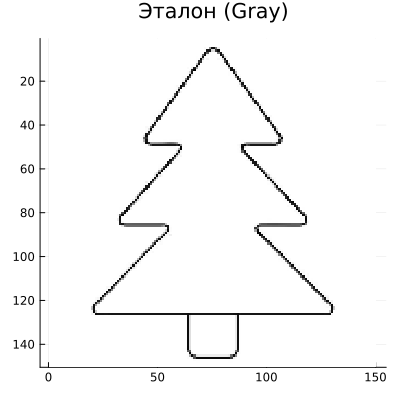

In [5]:
TARGET_PATH = joinpath(LAB19_ROOT, "tree.jpg")

if TARGET_PATH != "" && isfile(TARGET_PATH)
    target_raw = load_target_gray(TARGET_PATH)
    target = target_raw
    @info "Эталон загружен" TARGET_PATH
end

p_target = heatmap(Gray.(target); aspect_ratio = 1, title = "Эталон (Gray)", size = (400, 400))
showplot(p_target)

┌ Info: Поколений (итераций отбора)
└   result.generation = 50
┌ Info: Лучшая приспособленность
└   result.f_parent = -106.80728939153963


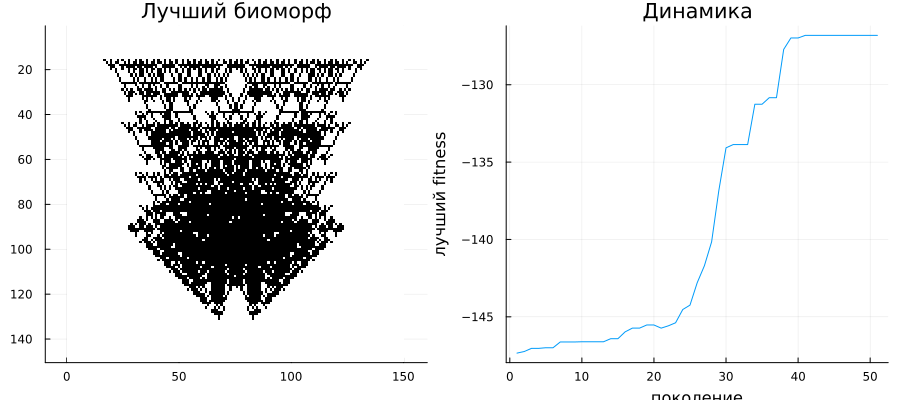

In [6]:
Random.seed!(42)
N_POP = 24
FITNESS = EuclideanDist  # EuclideanDist / ManhattanDist / NCC
LINE_HALF_WIDTH = 0  


result = evolve_biomorph(
    target;
    N = N_POP,
    max_stagnation = 10,
    mode = FITNESS,
    line_half_width = LINE_HALF_WIDTH,
    init_color = (9, 2, 1),
    target_color = (0, 0, 0),
    colorλ = 20.0,
    color_ramp_gens = 20,
    color_mut_p = 0.25,
)

@info "Поколений (итераций отбора)" result.generation
@info "Лучшая приспособленность" result.f_parent

p1 = heatmap(biomorph_image(result.parent; line_half_width = result.line_half_width); aspect_ratio = 1, title = "Лучший биоморф")
p2 = plot(result.history_f; legend = false, xlabel = "поколение", ylabel = "лучший fitness", title = "Динамика")
p_run = plot(p1, p2; layout = (1, 2), size = (900, 400))
showplot(p_run)

In [7]:
println("Лучший генотип (19 целых): ", result.parent)

Лучший генотип (19 целых): [2, -2, -3, 2, 2, -4, 0, 4, -2, -4, 4, 2, -2, -5, 0, 12, 0, 0, 0]


[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab20\biomorph_evolution_tree.gif
┌ Info: GIF эволюции сохранён
└   evol_gif_path = "D:\\Programming\\Projects\\8 Semestr\\Optimization\\lab20\\biomorph_evolution_tree.gif"


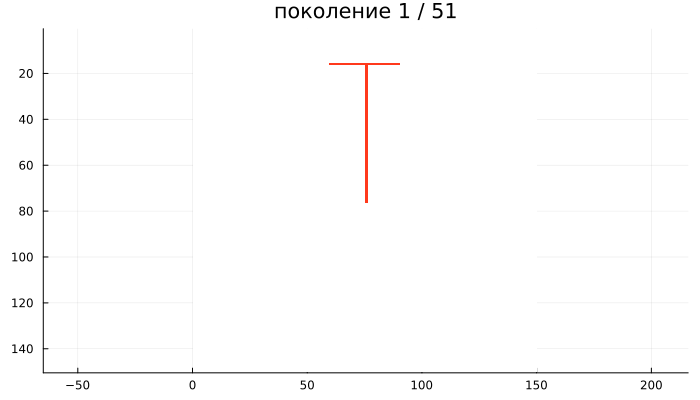

Эволюция tree (лучший по поколениям)


In [8]:
try
    default(fmt = :png)
    gr(fmt = :png)
catch
end

function gif_biomorph_frames(
    plot_i::Function,
    out_path::AbstractString,
    nframes::Int;
    fps::Real = 2,
)
    d = mktempdir(plot_cache_dir(); prefix = "lab19_gif_")
    anim = Animation(d, String[])
    prev_show = Plots.default(:show)
    default(show = false)
    try
        for i in 1:nframes
            plot_i(i)
            frame(anim)
            closeall()
        end
        gif(anim, String(out_path); fps = fps)
    finally
        default(show = prev_show)
        isdir(d) && rm(d; recursive = true)
        closeall()
    end
    return out_path
end

function show_gif_in_notebook(path::AbstractString; title::AbstractString = "")
    display(MIME("image/gif"), read(path))
    isempty(title) || println(title)
    closeall()
    return nothing
end


evol_gif_path = joinpath(LAB19_ROOT, "biomorph_evolution_tree.gif")
histg = result.history_genes
Ne = length(histg)
gif_biomorph_frames(evol_gif_path, Ne; fps = 2) do i
    g = histg[i]
    heatmap(
        biomorph_image(g; line_half_width = result.line_half_width);
        aspect_ratio = 1,
        title = "поколение $i / $Ne",
        colorbar = false,
    )
end
@info "GIF эволюции сохранён" evol_gif_path
show_gif_in_notebook(evol_gif_path; title = "Эволюция tree (лучший по поколениям)")


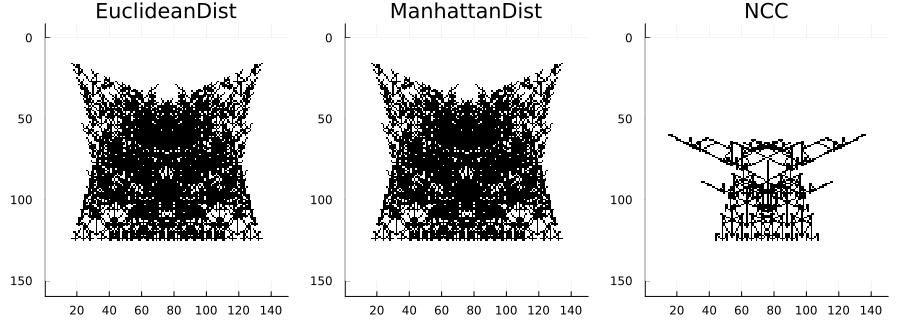

In [9]:
g0 = random_genotype(Random.Xoshiro(1))
# фиксируем стартовый яркий цвет, чтобы метрики не были "случайно тёмно-синие"
g0[BASE_GENE_COUNT+1:GENE_COUNT] .= (9, 2, 1)
figs = []
for mode in (EuclideanDist, ManhattanDist, NCC)
    Random.seed!(1)
    r = evolve_biomorph(target; N = 16, max_stagnation = 10, mode, init = g0, line_half_width = LINE_HALF_WIDTH, target_color = (0, 0, 0), colorλ = 20.0, color_ramp_gens = 20, color_mut_p = 0.25)
    gshow = force_color(r.parent, (0, 0, 0))
    push!(figs, heatmap(biomorph_image(gshow; line_half_width = r.line_half_width); title = string(mode), aspect_ratio = 1, colorbar = false))
end
p_metrics = plot(figs...; layout = (1, 3), size = (900, 320))
showplot(p_metrics)

┌ Info: Эталон загружен
└   TARGET_PATH = "D:\\Programming\\Projects\\8 Semestr\\Optimization\\lab20\\bat.jpg"


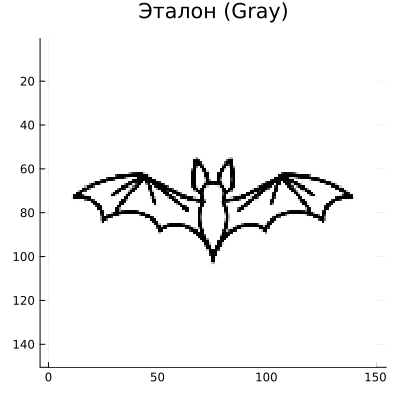

┌ Info: Поколений (bat)
└   result.generation = 40
┌ Info: Лучшая приспособленность (bat)
└   result.f_parent = 20.024648398144883


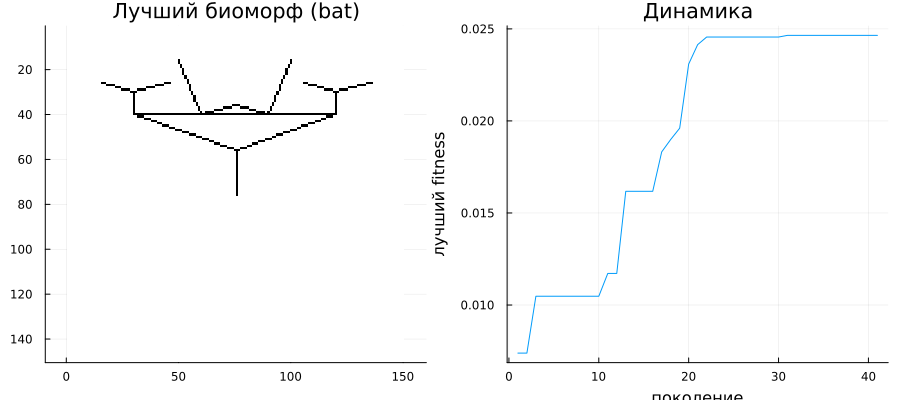

In [10]:
TARGET_PATH = joinpath(LAB19_ROOT, "bat.jpg")

if TARGET_PATH != "" && isfile(TARGET_PATH)
    target_raw = load_target_gray(TARGET_PATH)
    target = target_raw
    @info "Эталон загружен" TARGET_PATH
end

p_target = heatmap(Gray.(target); aspect_ratio = 1, title = "Эталон (Gray)", size = (400, 400))
showplot(p_target)


Random.seed!(42)


result = evolve_biomorph(
    target;
    N = N_POP,
    max_stagnation = 10,
    mode = NCC,
    line_half_width = LINE_HALF_WIDTH,
    init_color = (9, 2, 1),
    target_color = (0, 0, 0),
    colorλ = 20.0,
    color_ramp_gens = 20,
    color_mut_p = 0.25,
)
@info "Поколений (bat)" result.generation
@info "Лучшая приспособленность (bat)" result.f_parent
p1 = heatmap(biomorph_image(result.parent; line_half_width = result.line_half_width); aspect_ratio = 1, title = "Лучший биоморф (bat)")
p2 = plot(result.history_f; legend = false, xlabel = "поколение", ylabel = "лучший fitness", title = "Динамика")
p_run = plot(p1, p2; layout = (1, 2), size = (900, 400))
showplot(p_run)


[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab20\biomorph_evolution_bat.gif
┌ Info: GIF эволюции сохранён
└   evol_gif_path = "D:\\Programming\\Projects\\8 Semestr\\Optimization\\lab20\\biomorph_evolution_bat.gif"


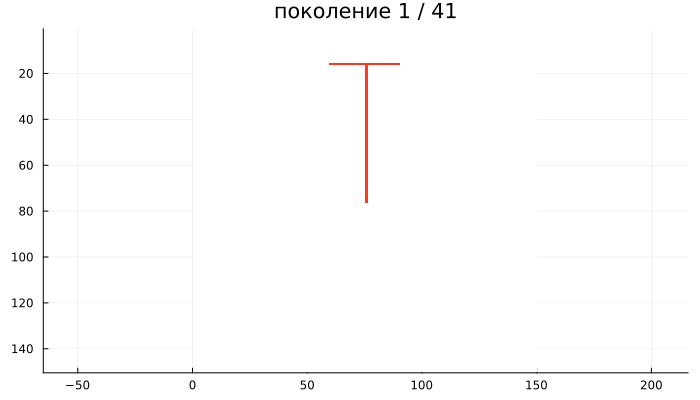

Эволюция bat (лучший по поколениям)


In [11]:
evol_gif_path = joinpath(LAB19_ROOT, "biomorph_evolution_bat.gif")
histg = result.history_genes
Ne = length(histg)
gif_biomorph_frames(evol_gif_path, Ne; fps = 2) do i
    g = histg[i]
    heatmap(
        biomorph_image(g; line_half_width = result.line_half_width);
        aspect_ratio = 1,
        title = "поколение $i / $Ne",
        colorbar = false,
    )
end
@info "GIF эволюции сохранён" evol_gif_path
show_gif_in_notebook(evol_gif_path; title = "Эволюция bat (лучший по поколениям)")


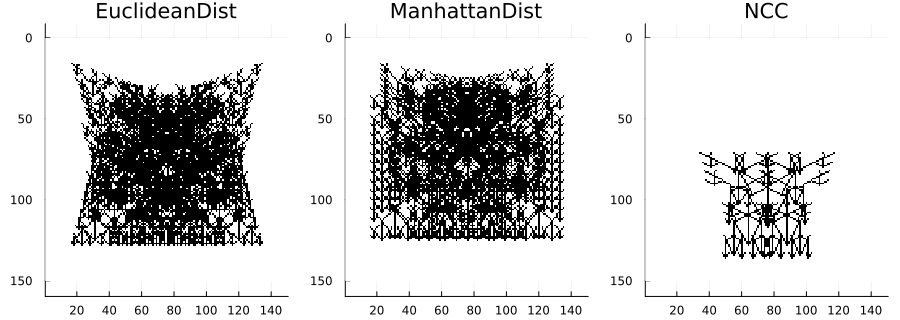

In [12]:
g0 = random_genotype(Random.Xoshiro(1))
# фиксируем стартовый яркий цвет, чтобы метрики не были "случайно тёмно-синие"
g0[BASE_GENE_COUNT+1:GENE_COUNT] .= (9, 2, 1)
figs = []
for mode in (EuclideanDist, ManhattanDist, NCC)
    Random.seed!(1)
    r = evolve_biomorph(target; N = 16, max_stagnation = 10, mode, init = g0, line_half_width = LINE_HALF_WIDTH, target_color = (0, 0, 0), colorλ = 20.0, color_ramp_gens = 20, color_mut_p = 0.25)
    gshow = force_color(r.parent, (0, 0, 0))
    push!(figs, heatmap(biomorph_image(gshow; line_half_width = r.line_half_width); title = string(mode), aspect_ratio = 1, colorbar = false))
end
p_metrics = plot(figs...; layout = (1, 3), size = (900, 320))
showplot(p_metrics)

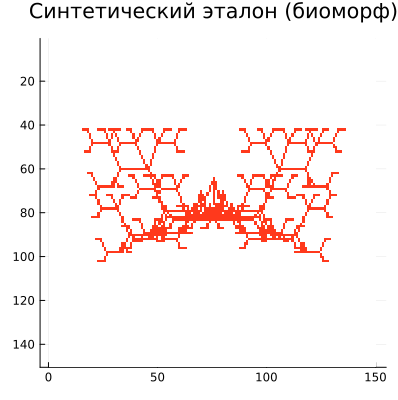

┌ Info: Синтетика: fitness старта к эталону
└   fitness(Ft, p0, target) = 0.02565785460931364
┌ Info: Синтетика: поколений
└   result.generation = 52
┌ Info: Синтетика: лучшая приспособленность
└   result.f_parent = 25.331161706153868


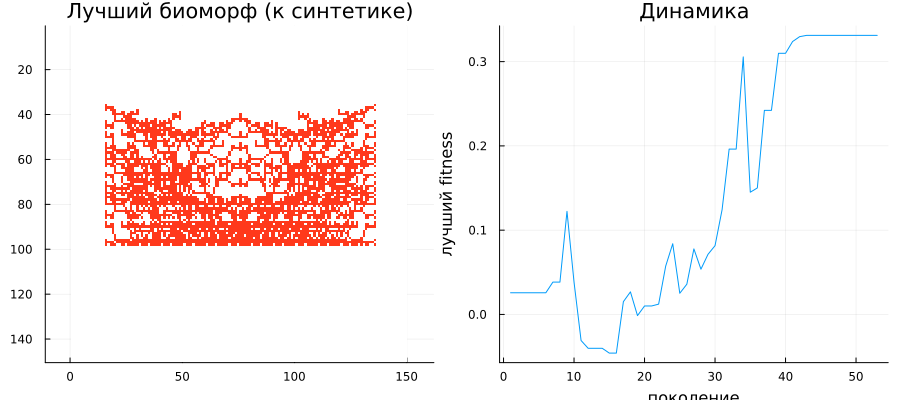

[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\lab20\biomorph_evolution_synth.gif
┌ Info: GIF (синтетика) сохранён
└   evol_gif_path = "D:\\Programming\\Projects\\8 Semestr\\Optimization\\lab20\\biomorph_evolution_synth.gif"


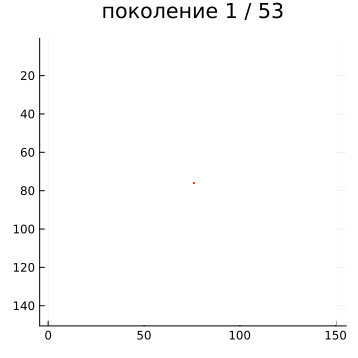

Эволюция к синтетическому эталону


In [13]:
synth_ref_genes = Int[2, 1, -3, 4, 2, -5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 9, 2, 1]

lw = isdefined(Main, :LINE_HALF_WIDTH) ? LINE_HALF_WIDTH : 1
target = biomorph_raster(synth_ref_genes; line_half_width = lw)

p_target = heatmap(biomorph_image(synth_ref_genes; line_half_width = lw); aspect_ratio = 1, title = "Синтетический эталон (биоморф)", size = (400, 400), colorbar = false)
showplot(p_target)

Random.seed!(42)
Nsynth = isdefined(Main, :N_POP) ? N_POP : 24  
Ft = NCC

synth_fitness_goal = fitness(Ft, target, target)

SYNTH_EARLY_STOP_OFFSPRING = true


synth_start = Int[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 9, 2, 1]
p0 = biomorph_raster(synth_start; line_half_width = lw)
@info "Синтетика: fitness старта к эталону" fitness(Ft, p0, target)


SYNTH_MAX_GENERATIONS = 52
SYNTH_GIF_FRAMES = 24

result = evolve_biomorph(
    target;
    N = Nsynth,
    max_stagnation = 12,
    mode = Ft,
    line_half_width = lw,
    init = synth_start,
    target_color = (synth_ref_genes[BASE_GENE_COUNT+1], synth_ref_genes[BASE_GENE_COUNT+2], synth_ref_genes[BASE_GENE_COUNT+3]),
    colorλ = 25.0,
    color_ramp_gens = 20,
    color_mut_p = 0.25,
    sa_temperature = 5.0,
    sa_decay = 0.997,
    max_generations = SYNTH_MAX_GENERATIONS,
    fitness_goal = synth_fitness_goal,
    early_stop_offspring = SYNTH_EARLY_STOP_OFFSPRING,
)

@info "Синтетика: поколений" result.generation
@info "Синтетика: лучшая приспособленность" result.f_parent

p1 = heatmap(biomorph_image(result.parent; line_half_width = result.line_half_width); aspect_ratio = 1, title = "Лучший биоморф (к синтетике)")
p2 = plot(result.history_f; legend = false, xlabel = "поколение", ylabel = "лучший fitness", title = "Динамика")
p_run = plot(p1, p2; layout = (1, 2), size = (900, 400))
showplot(p_run)

evol_gif_path = joinpath(LAB19_ROOT, "biomorph_evolution_synth.gif")
histg = result.history_genes
Ne = length(histg)
gif_idx =
    Ne <= SYNTH_GIF_FRAMES ? collect(1:Ne) :
    unique(round.(Int, range(1, Ne; length = SYNTH_GIF_FRAMES)))
Ngif = length(gif_idx)
gif_biomorph_frames(evol_gif_path, Ngif; fps = 2) do i
    j = gif_idx[i]
    g = histg[j]
    heatmap(
        biomorph_image(g; line_half_width = result.line_half_width);
        aspect_ratio = 1,
        size = (360, 360),
        title = "поколение $j / $Ne",
        colorbar = false,
    )
end
@info "GIF (синтетика) сохранён" evol_gif_path
show_gif_in_notebook(evol_gif_path; title = "Эволюция к синтетическому эталону")


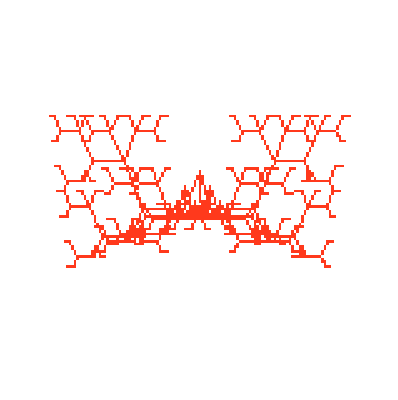

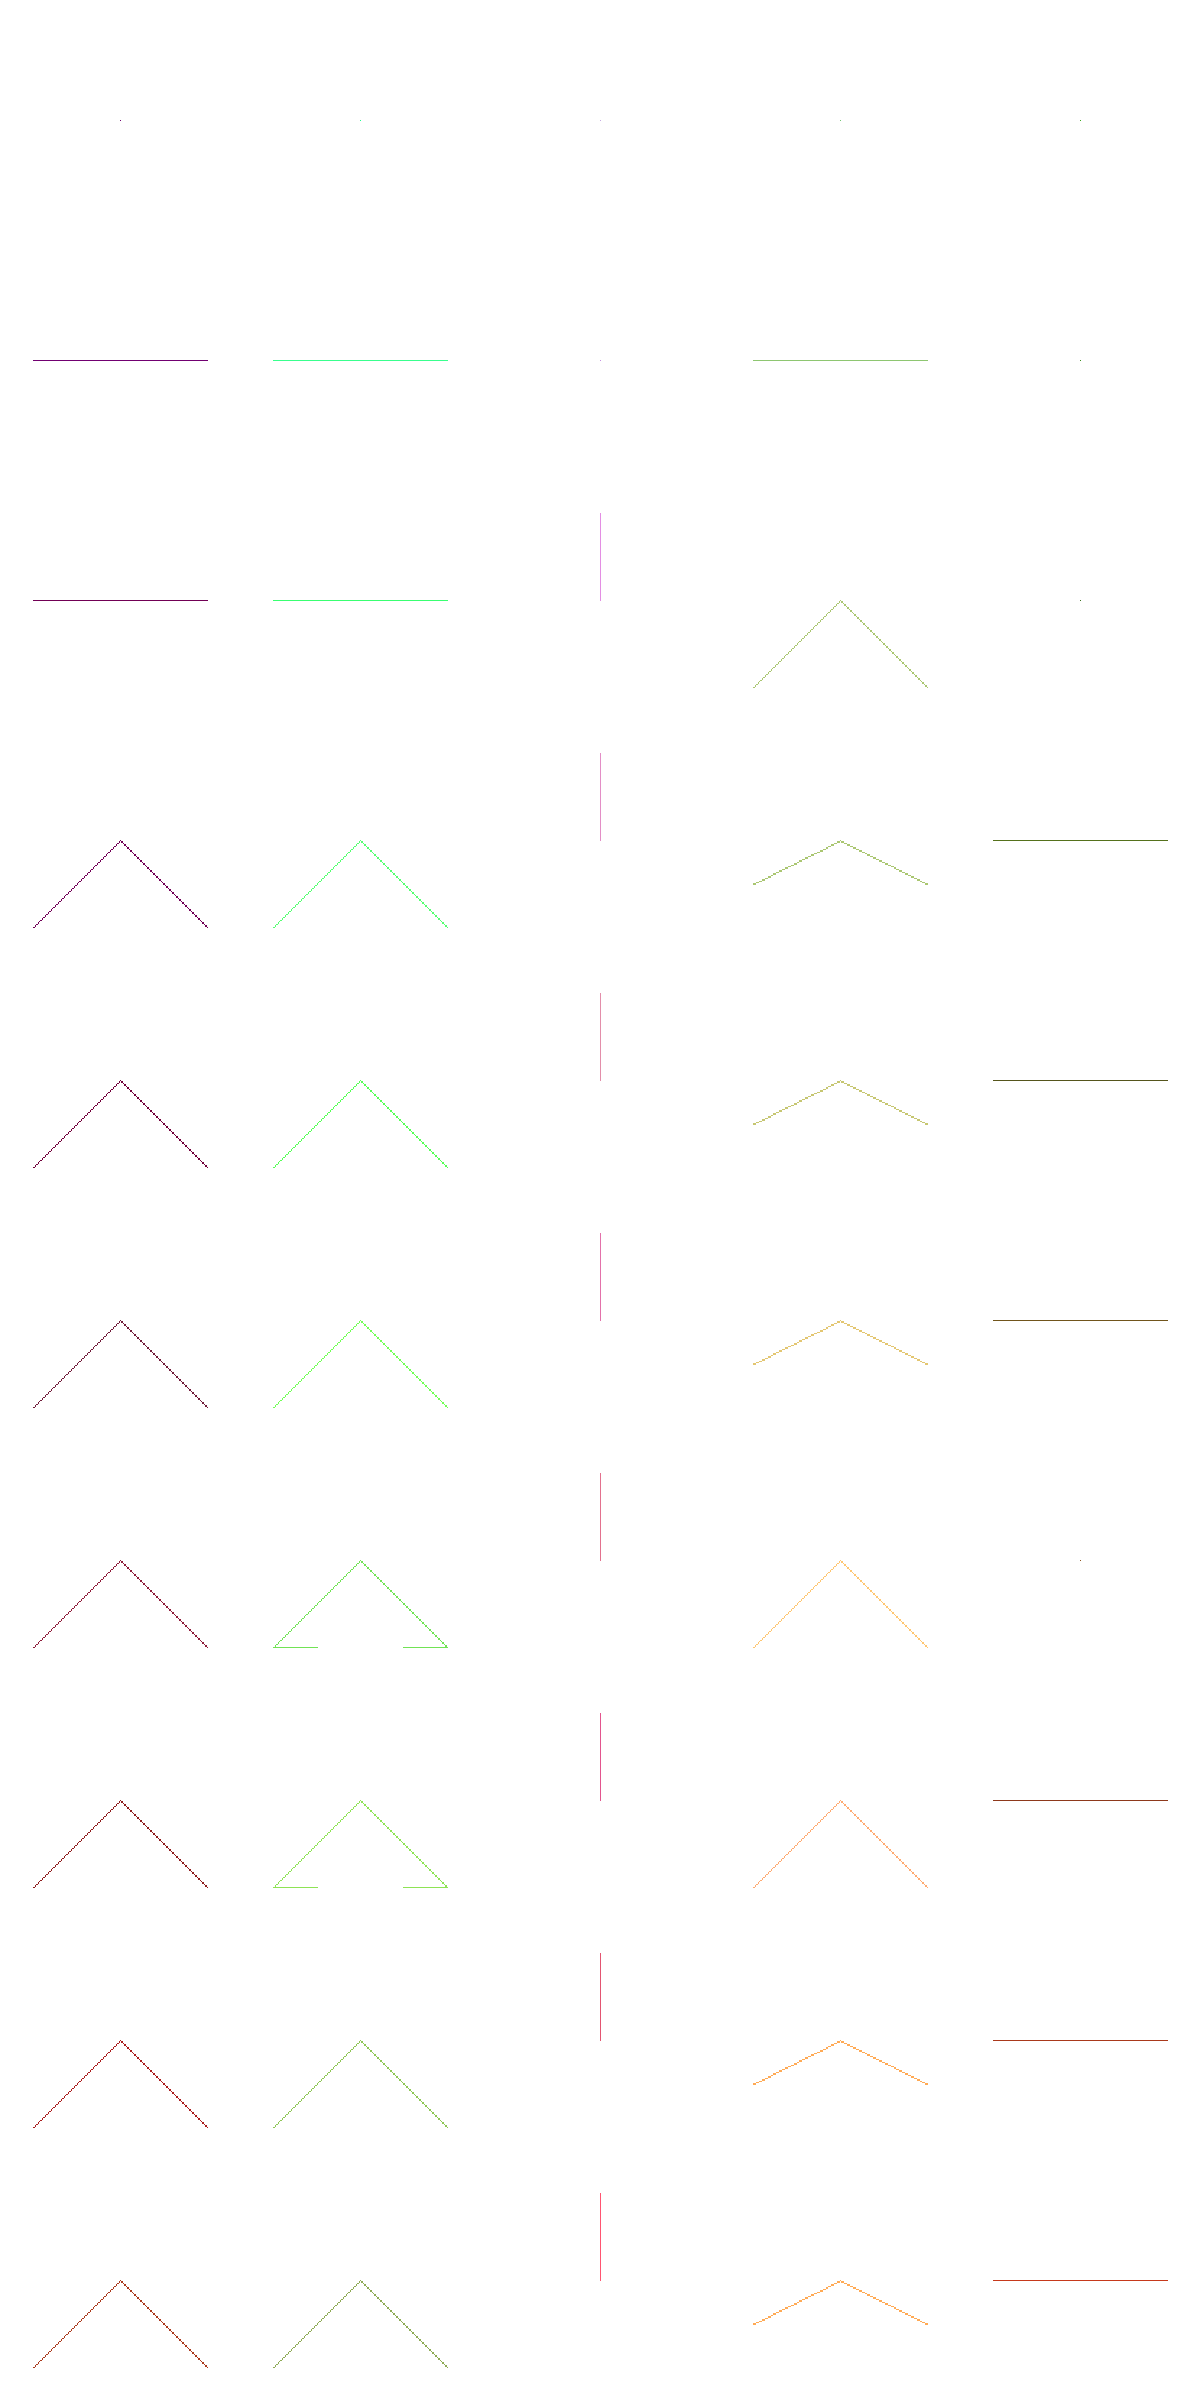

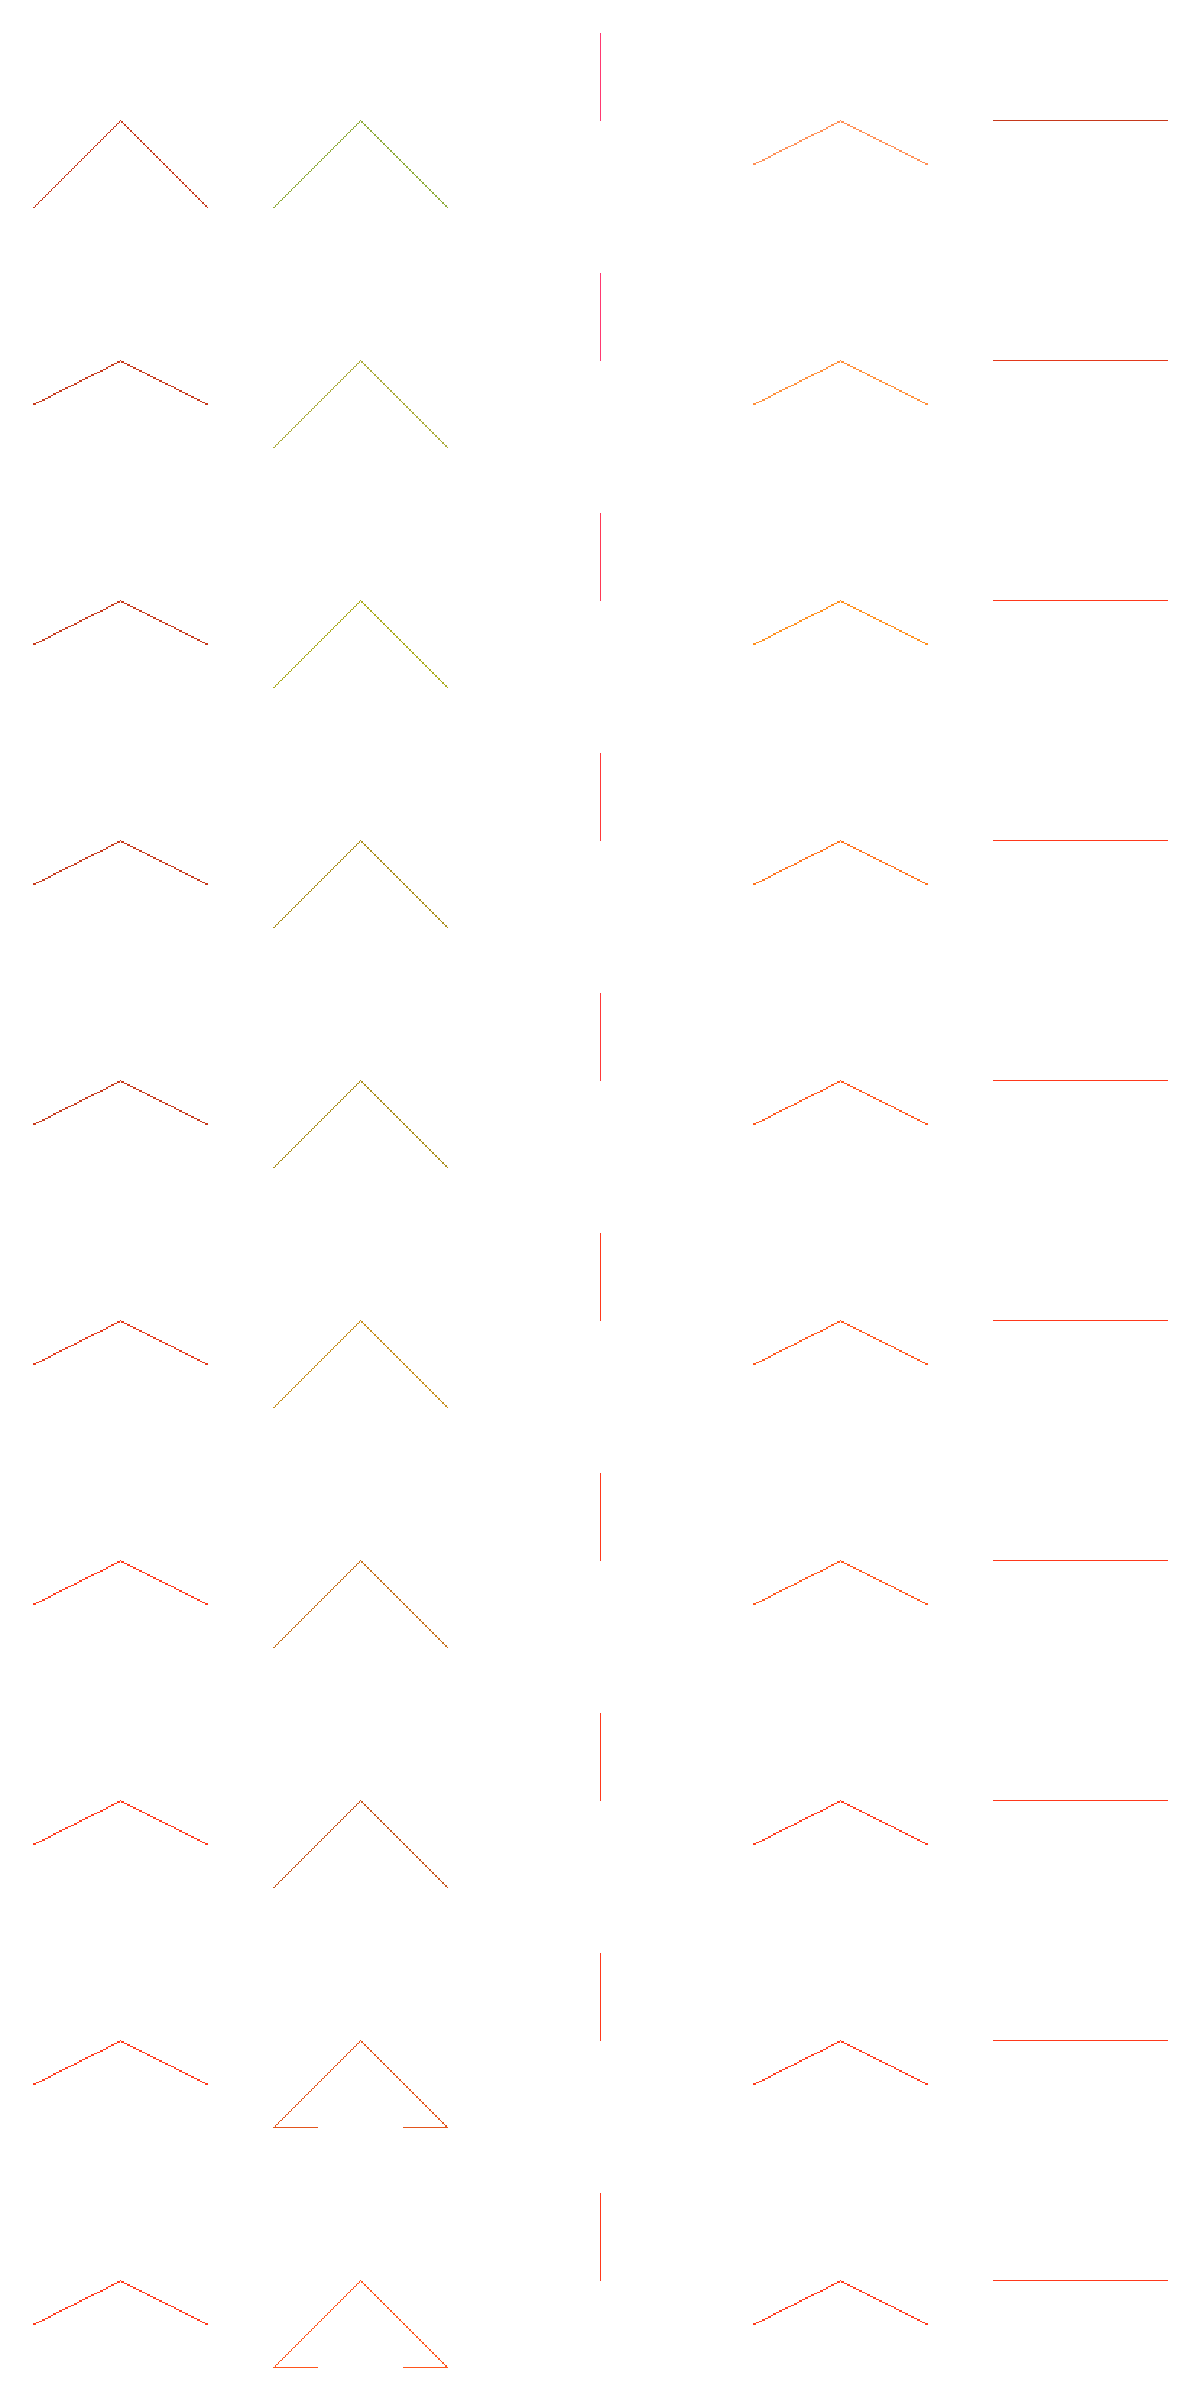

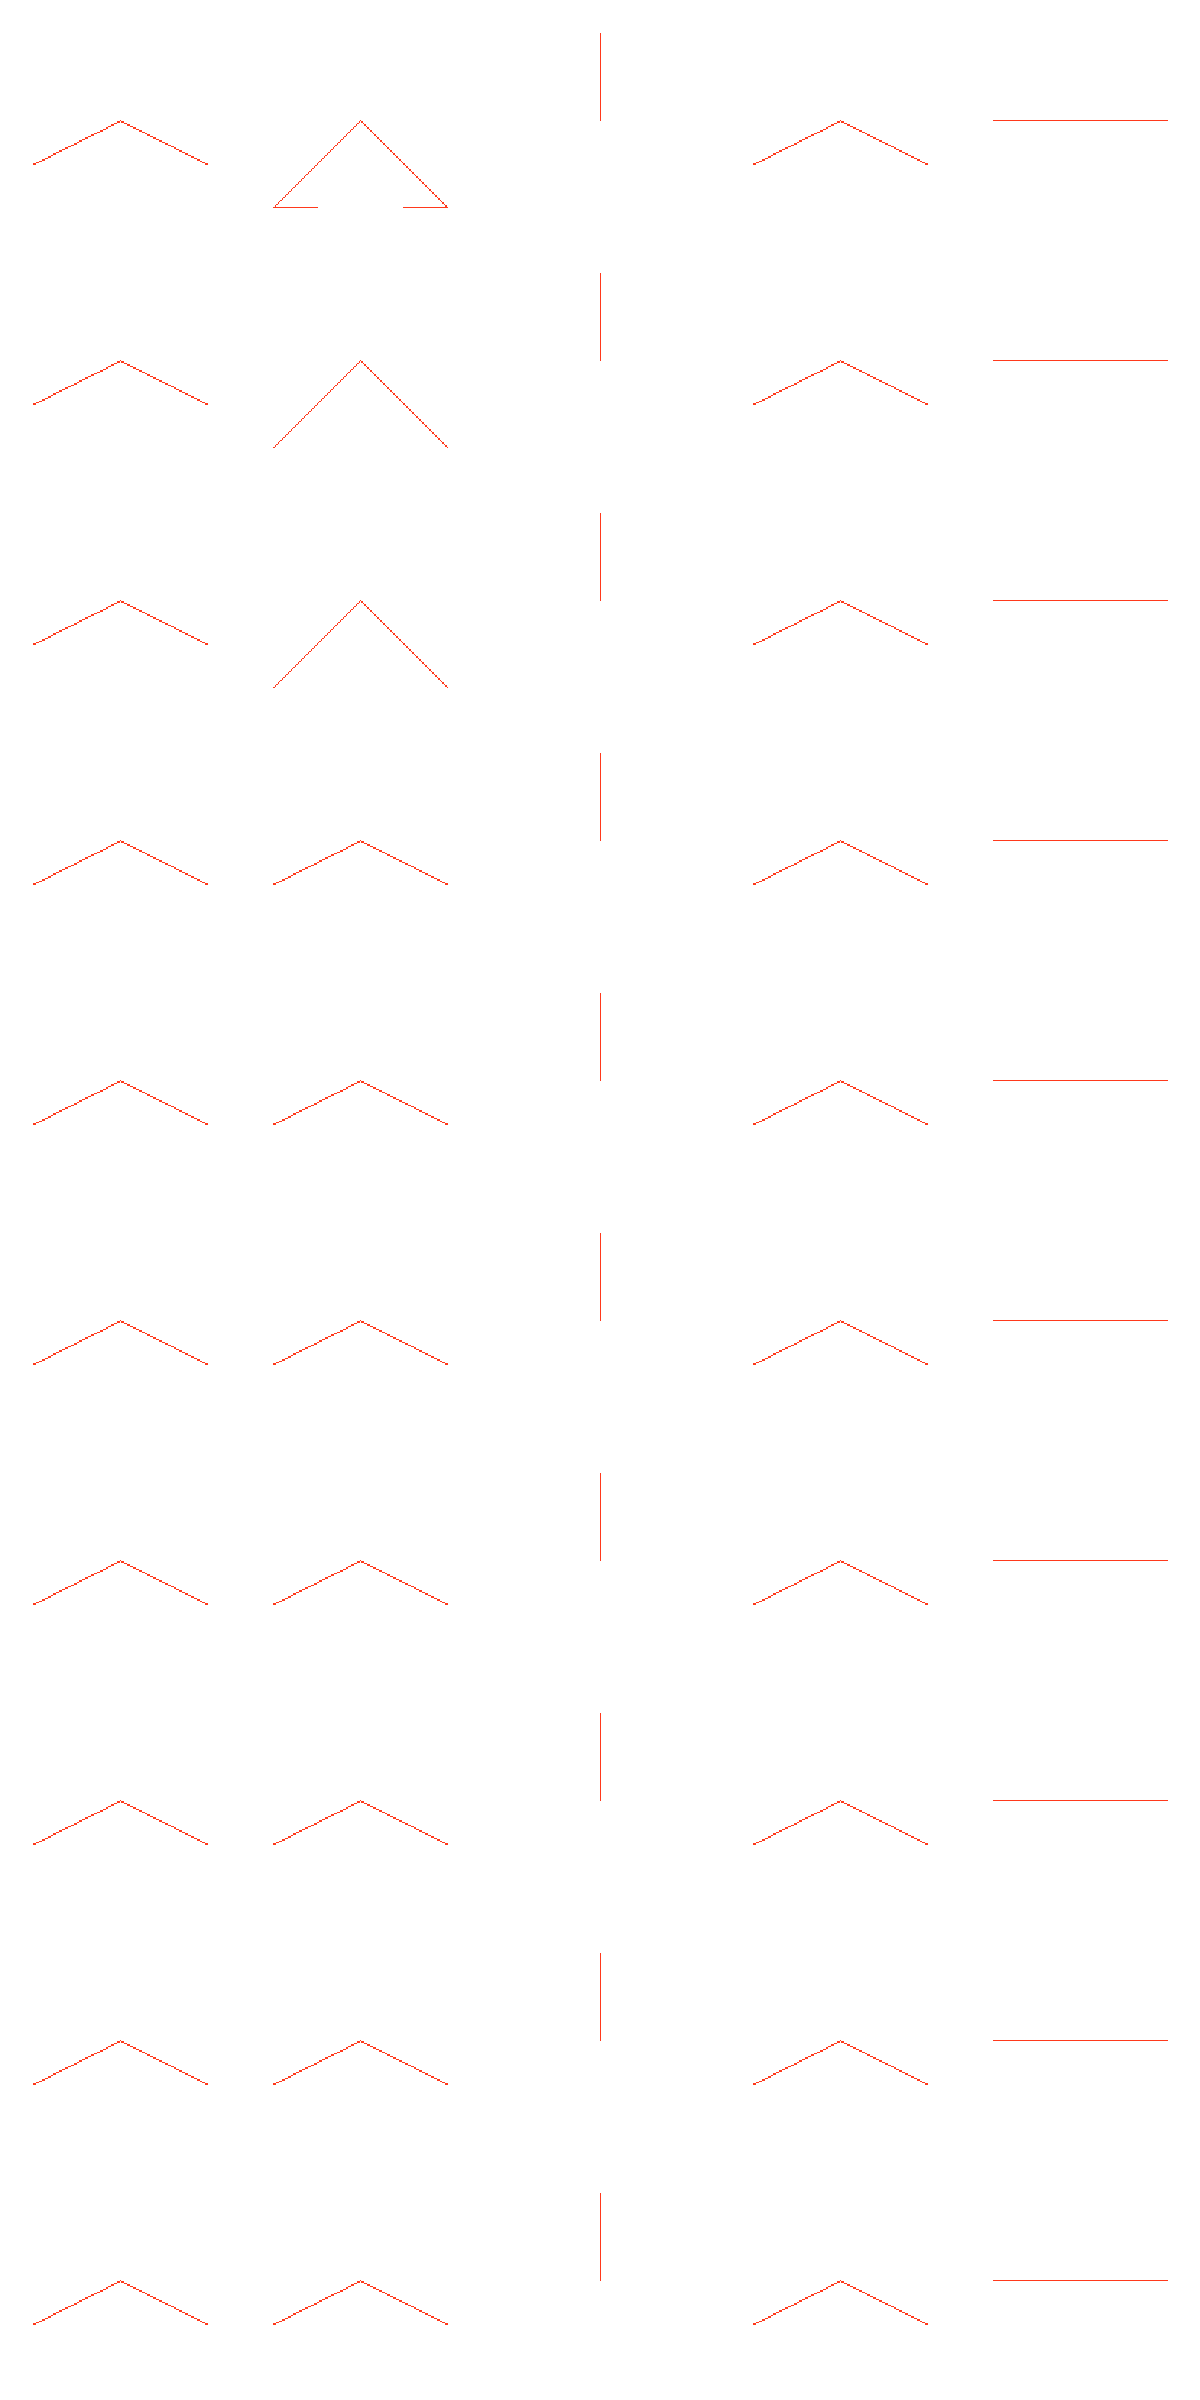

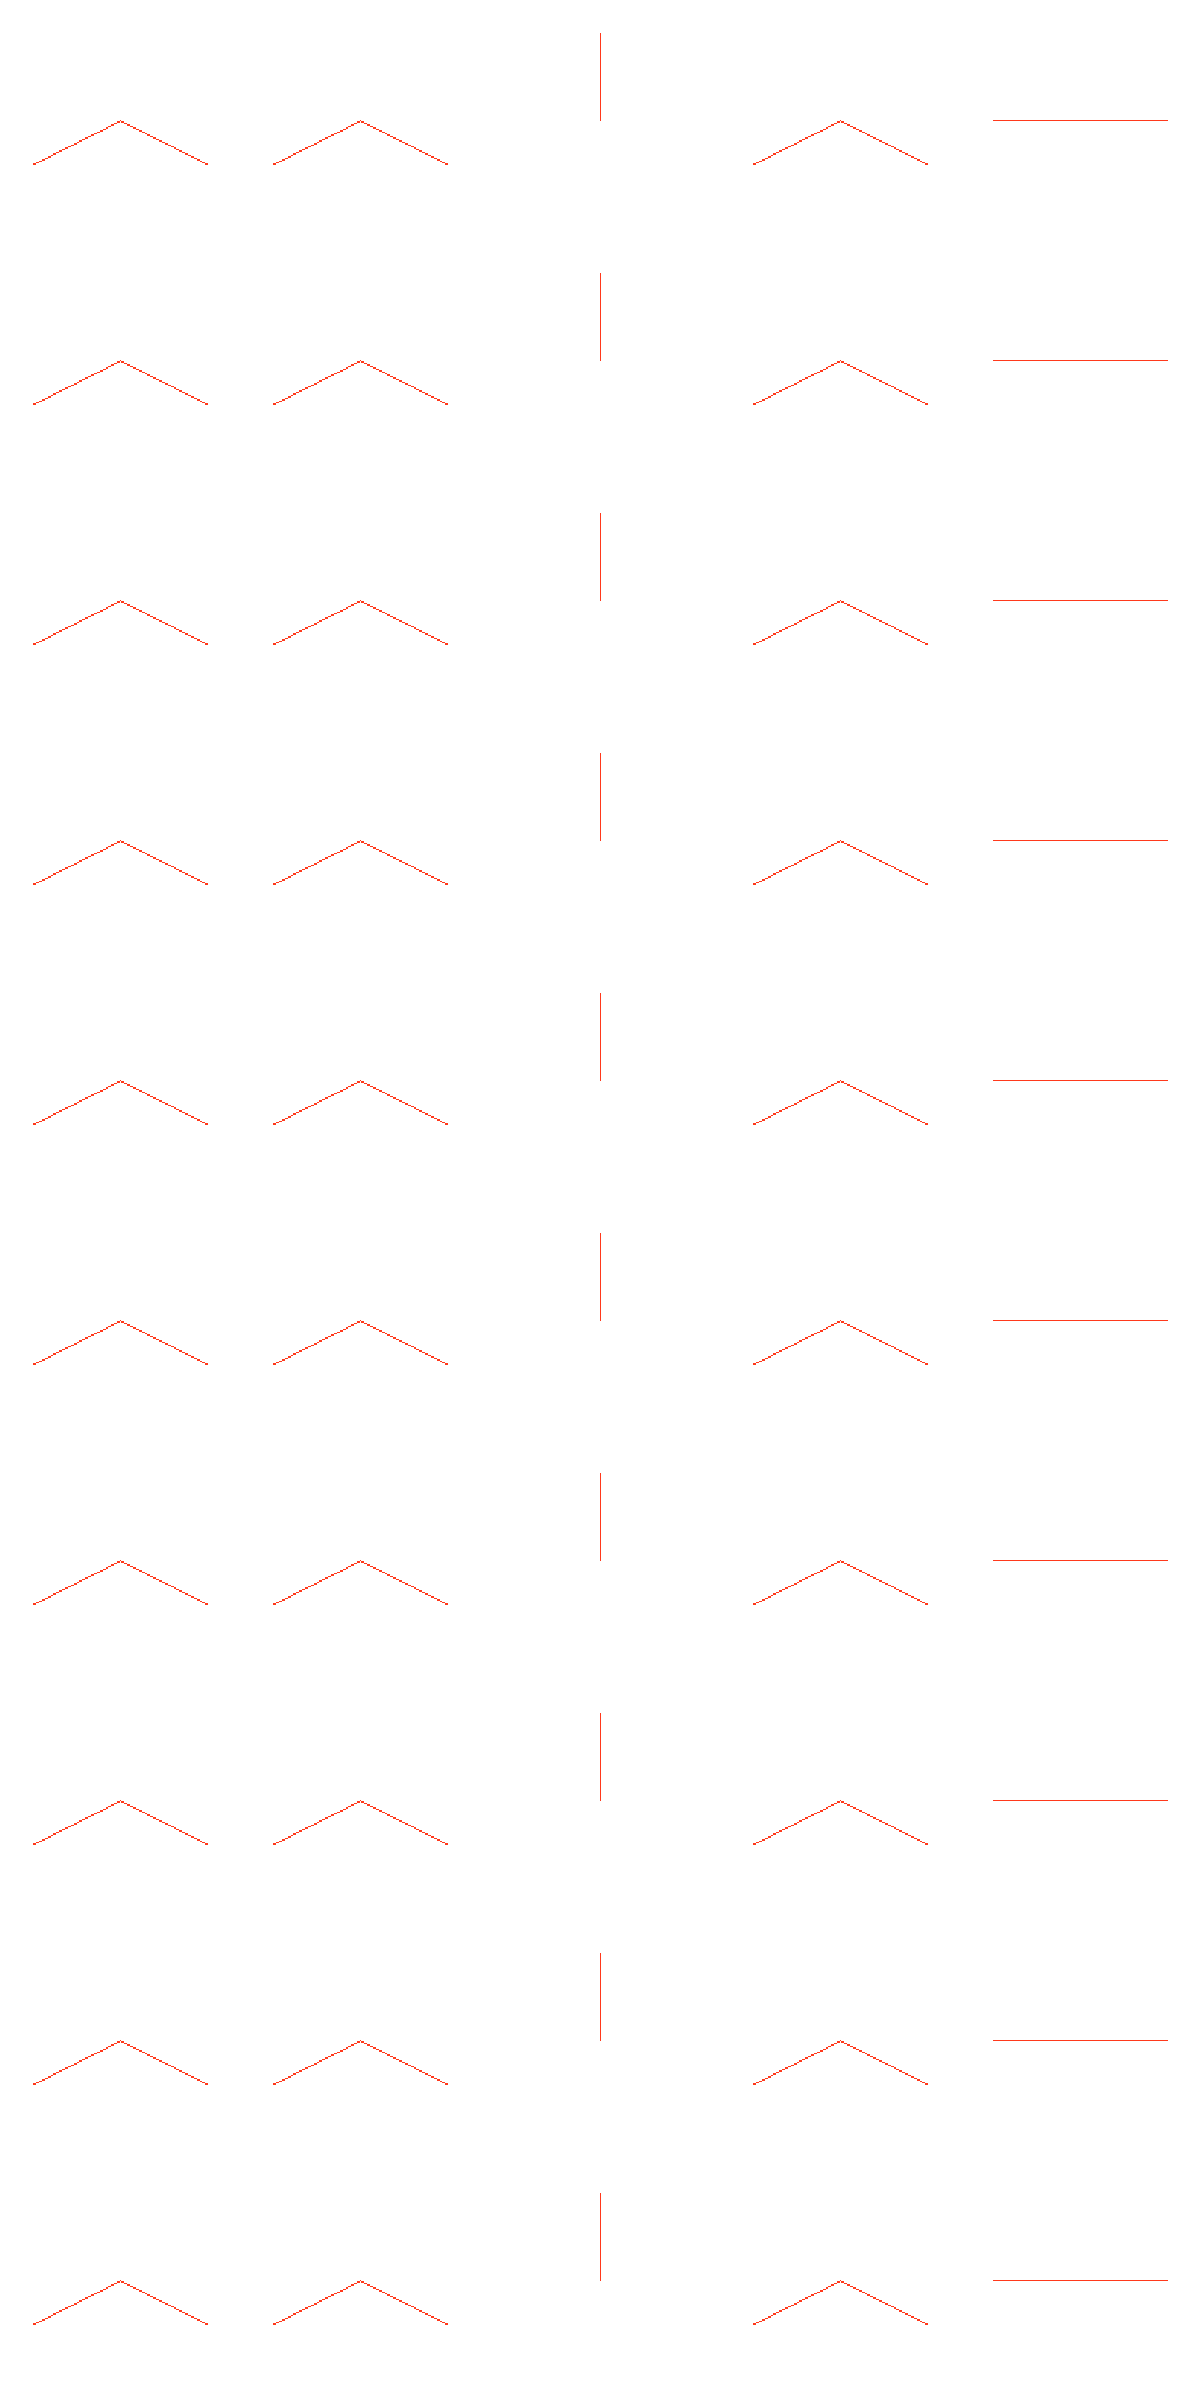

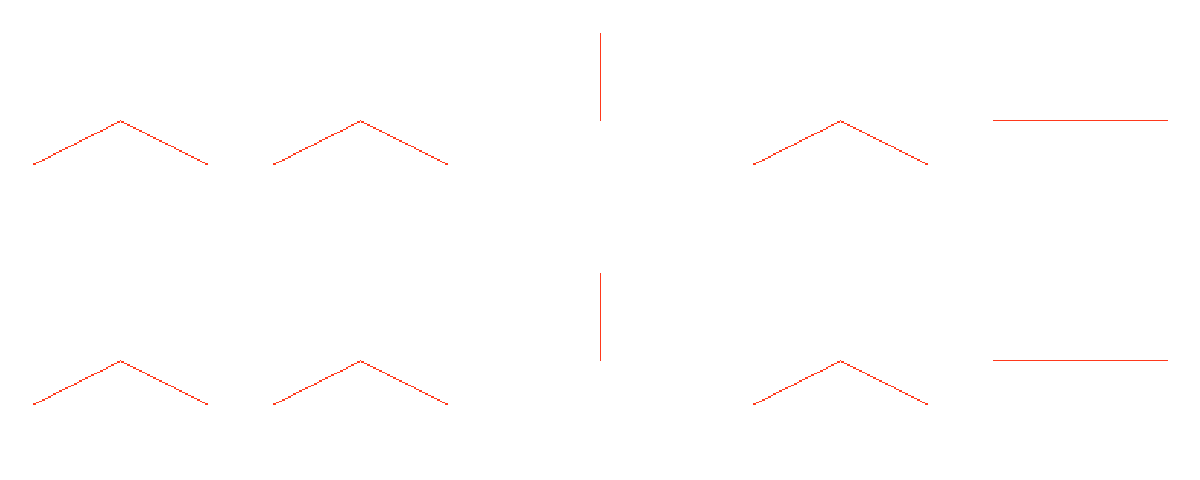

In [14]:
N_LINEAGES = 5
WARMUP_MUTATIONS = 0  # как в исходном варианте: стартуем из "точки"
lw_r = isdefined(Main, :LINE_HALF_WIDTH) ? LINE_HALF_WIDTH : 0
ref_genes = Int[2, 1, -3, 4, 2, -5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 9, 2, 1]
target_r = biomorph_raster(ref_genes; line_half_width = lw_r)

# Старт из "точки": все направления 0, Lrec минимальный.
line0 = Int[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0]
ref_rgb = (ref_genes[BASE_GENE_COUNT+1], ref_genes[BASE_GENE_COUNT+2], ref_genes[BASE_GENE_COUNT+3])
Ft_r = isdefined(Main, :Ft) ? Ft : (isdefined(Main, :FITNESS) ? FITNESS : NCC)
Npop_r = isdefined(Main, :N_POP) ? N_POP : 24
inits_r = Vector{Vector{Int}}(undef, N_LINEAGES)

for c in 1:N_LINEAGES
    g = copy(line0)
    rng_w = Random.Xoshiro(10_000 + c)

    # Разные стартовые цвета.
    for i in (BASE_GENE_COUNT + 1):GENE_COUNT
        g[i] = rand(rng_w, 0:9)
    end

    for _ in 1:WARMUP_MUTATIONS
        g = mutate_one(g, rng_w)
    end

    inits_r[c] = g
end
RACE_MAX_GEN = 45
RACE_STAG = 18
runs_r = map(1:N_LINEAGES) do c
    evolve_biomorph(
        target_r;
        N = Npop_r,
        max_stagnation = RACE_STAG,
        max_generations = RACE_MAX_GEN,
        mode = Ft_r,
        init = inits_r[c],
        rng = Random.Xoshiro(20_000 + c),
        line_half_width = lw_r,
        target_color = ref_rgb,
        colorλ = 20.0,
        color_ramp_gens = 20,
        color_mut_p = 0.25,
        early_stop_offspring = false,
        fitness_goal = nothing,
    )
end
function _biomorph_heatmap_plain(genes::Vector{Int}; lw::Int = 0, px::Int = 120)
    heatmap(
        biomorph_image(genes; line_half_width = lw);
        aspect_ratio = 1,
        colorbar = false,
        ticks = false,
        showaxis = false,
        grid = false,
        legend = false,
        framestyle = :none,
        widen = false,
        size = (px, px),
    )
end
HM_TARGET = 400
showplot(_biomorph_heatmap_plain(ref_genes; lw = lw_r, px = HM_TARGET))

function _state_at_row(r, row::Int)
    h = r.history_genes
    h[min(row, length(h))]
end
Lmax = maximum(length.(getproperty.(runs_r, :history_genes)))
HM_CELL = 240
ROWS_PER_PAGE = 10
pages = cld(Lmax, ROWS_PER_PAGE)
for p in 1:pages
    row_start = (p - 1) * ROWS_PER_PAGE + 1
    row_end = min(Lmax, p * ROWS_PER_PAGE)
    nrows = row_end - row_start + 1
    tab_cells = []
    for row in row_start:row_end
        for c in 1:N_LINEAGES
            g = _state_at_row(runs_r[c], row)
            push!(
                tab_cells,
                _biomorph_heatmap_plain(g; lw = lw_r, px = HM_CELL),
            )
        end
    end
    p_table = plot(
        tab_cells...;
        layout = (nrows, N_LINEAGES),
        size = (N_LINEAGES * HM_CELL, nrows * HM_CELL),
        plot_title = "",
    )
    showplot(p_table)
end


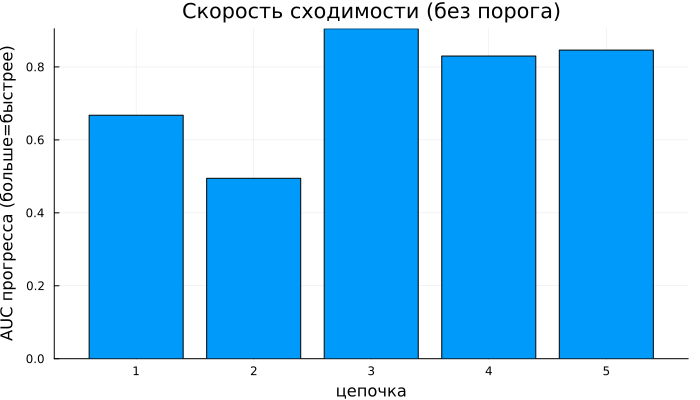

┌ Info: лучшая по AUC
│   argmax(scores) = 3
└   maximum(scores) = 0.9047619047619048


In [15]:
goal = fitness(Ft_r, target_r, target_r)
THRESH = 0.95
function auc_progress(hf::Vector{Float64})
    f0, fend = hf[1], maximum(hf)
    denom = fend - f0
    denom <= 0 && return 0.0
    sum((f - f0)/denom for f in hf) / length(hf)
end
scores = [auc_progress(r.history_f) for r in runs_r]
p_auc = bar(1:N_LINEAGES, scores; legend=false,
    xlabel="цепочка", ylabel="AUC прогресса (больше=быстрее)",
    title="Скорость сходимости (без порога)")
showplot(p_auc)
@info "лучшая по AUC" argmax(scores) maximum(scores)